# Poznań Real Estate Market Analysis & Rent Predictor
**Author:** Kyrylo Kudrevych | **Role:** Data Engineer & Data Scientist

## 1. Project Overview
The goal of this project is to build an automated data pipeline that scrapes live real estate listings in Poznań, cleans the raw JSON data, and trains a Machine Learning model to predict fair market rent prices.

This notebook covers **Data Cleaning, Exploratory Data Analysis (EDA), and V1 Modeling.**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Load the raw scraped data
df = pd.read_csv("../data/raw_rent_data.csv")

## 2. Data Cleaning & Type Conversion
The raw data scraped from the API contains nested dictionaries saved as strings. We use Python's `ast` to evaluate these strings and extract pure numerical values, then calculate our target variable: `true_price` (Total Rent + Administrative Rent).

In [2]:
def extract_value(price_string):
    if isinstance(price_string, (float, int)):
        return float(price_string)
    if pd.isna(price_string):
        return 0.0
    try:
        price_dict = ast.literal_eval(price_string)
        return float(price_dict.get('value', 0.0))
    except (ValueError, SyntaxError):
        return 0.0

df['total_price'] = df['total_price'].apply(extract_value)
df['rent_price'] = df['rent_price'].apply(extract_value)
df['true_price'] = df['total_price'] + df['rent_price']

# Drop rows missing critical location data
df = df.dropna(subset=['location'])

## 3. Handling Ordinal Features
Variables like `floor` and `rooms` are Ordinal. We map these to integers and impute missing values using the statistical mode.

In [3]:
floor_mapping = {
    'CELLAR': -1, 'GROUND': 0, 'FIRST': 1, 'SECOND': 2,
    'THIRD': 3, 'FOURTH': 4, 'FIFTH': 5, 'SIXTH': 6,
    'SEVENTH': 7, 'EIGHTH': 8, 'NINTH': 9, 'TENTH': 10,
    'ABOVE_TENTH': 11, 'GARRET': 12
}

rooms_mapping = {
    "ONE": 1, "TWO": 2, "THREE": 3, "FOUR": 4,
    "FIVE": 5, "SIX": 6, "SEVEN": 7
}

df['floor_num'] = df['floor'].map(floor_mapping).fillna(1.0).astype(int)
df['rooms_num'] = df['rooms'].map(rooms_mapping).fillna(1.0).astype(int)

## 4. Exploratory Data Analysis (EDA) & Outlier Detection
We filter the dataset based on realistic market boundaries to protect the model from human errors and extreme luxury outliers.

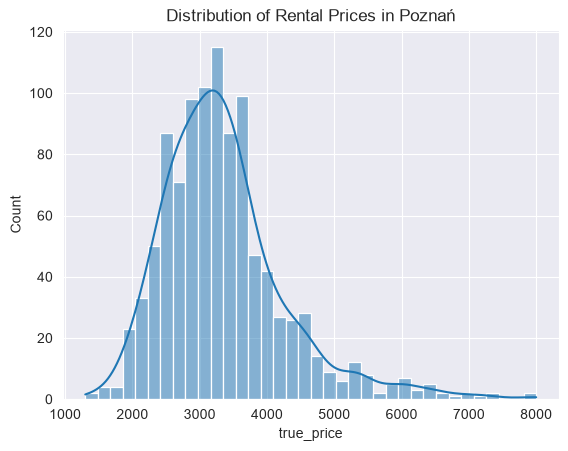

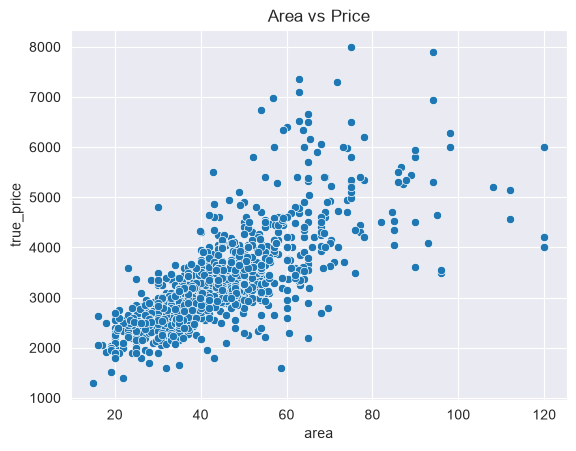

In [4]:
df = df[(df['area'] >= 15) & (df['area'] <= 120)]
df = df[(df['true_price'] >= 1200) & (df['true_price'] <= 8000)]

sns.histplot(df['true_price'], kde=True)
plt.title("Distribution of Rental Prices in Poznań")
plt.show()

sns.scatterplot(x="area", y="true_price", data=df)
plt.title("Area vs Price")
plt.show()

## 5. Feature Engineering: One-Hot Encoding
Neighborhood names are Nominal data. We use One-Hot Encoding to convert the text labels into distinct binary columns so the model can learn geographic price weightings.

In [5]:
df = pd.get_dummies(df, columns=['location'], dtype=int)
df = df.drop(columns=['id', 'title', 'total_price', 'rent_price', 'floor', 'rooms'])

## 6. Machine Learning: Random Forest Regressor
We use an ensemble tree-based model: the **Random Forest Regressor**, and split our data into an 80% Training Set and a 20% "Hidden" Test Set.

In [6]:
y = df['true_price']
X = df.drop(columns=['true_price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae:.2f} PLN")

Mean Absolute Error: 446.56 PLN


## 7. V1 Model Conclusion & Feature Importance
Our V1 baseline model achieved a solid MAE. Looking at the Reality Plot, the model suffers from *heteroscedasticity*, its error increases on expensive apartments. To optimize this model (V2), we must return to the data pipeline and scrape additional high-value features.

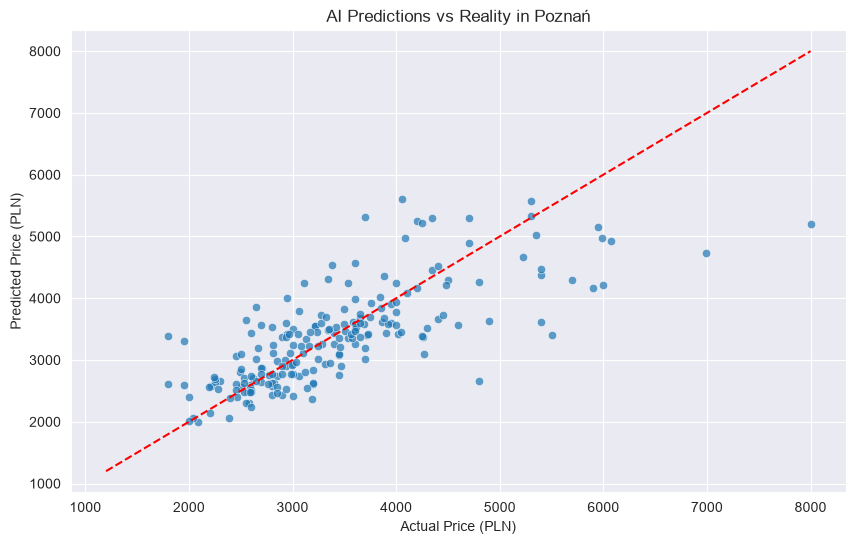


--- Top 10 Drivers of Real Estate Prices ---
                    Feature  Importance
0                      area    0.657183
2                 floor_num    0.058462
3                 rooms_num    0.057361
1            isPrivateOwner    0.021091
64          location_Łazarz    0.020814
18          location_Jeżyce    0.020632
14        location_Grunwald    0.016205
65  location_Łęgi Dębińskie    0.012671
48           location_Wilda    0.011443
41          location_Sołacz    0.010522


In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.7)
plt.plot([1200, 8000], [1200, 8000], color='red', linestyle='--')
plt.xlabel('Actual Price (PLN)')
plt.ylabel('Predicted Price (PLN)')
plt.title('AI Predictions vs Reality in Poznań')
plt.show()

importances = model.feature_importances_
feature_names = X_train.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10)
print("\n--- Top 10 Drivers of Real Estate Prices ---")
print(feature_df)

## 8. Conclusion & Key Findings

In this phase, we successfully transformed raw web-scraped JSON data into a clean, model-ready dataset and trained our baseline Machine Learning algorithm.

**Key Takeaways:**
1. **Model Performance:** The V1 Random Forest Regressor achieved a Mean Absolute Error (MAE) of **446.56 PLN**.
2. **Primary Price Drivers:** Feature importance analysis revealed that `area` dictates roughly 60% of the rent price, with `floor_num` and `rooms_num` being the next most important structural factors.
3. **Location & Ownership:** Districts like Łazarz, Grunwald, and Jeżyce command the highest location premiums. Additionally, whether a listing is managed by a private owner versus an agency significantly impacts the final price.

**Next Steps (V2 Optimization):**
While the MAE of 446.56 PLN is a strong baseline, the *Reality Plot* demonstrates heteroscedasticity, our model loses accuracy on luxury, high-end apartments. To resolve this, the next iteration will focus on upgrading the web scraper to extract premium amenities (e.g., parking spaces, air conditioning, balconies) to capture the missing variance in higher price tiers.